# 5.2: Notebook-Data cleaning fundamentals

## Learning objectives
By the end of this notebook, you will be able to:
- identify and handle duplicate records in datasets,
- detect and handle missing values using various strategies,
- identify outliers using statistical methods,
- make informed decisions about data cleaning approaches.

## Why data cleaning matters
Real-world data is rarely clean. It often contains:
- **duplicates**: same record entered multiple times,
- **missing values**: information not collected or lost,
- **outliers**: Unusual values that may indicate errors or rare cases.

These issues can lead to incorrect analysis and poor model performance. Data cleaning is often 70–80% of a data scientist's work!

## Setup and data loading

We'll work with an employee dataset that contains information about company employees, including their salaries, departments and performance metrics.

In [1]:
import pandas as pd
import numpy as np

# For minimal visualizations
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n_employees = 150

age = np.random.randint(22, 65, n_employees)
years_experience = np.array([
    np.random.randint(0, max(1, a - 18)) for a in age
])

data = {
    'employee_id': list(range(1001, 1001 + n_employees)),
    'name': [f'Employee_{i}' for i in range(1, n_employees + 1)],
    'department': np.random.choice(['Sales', 'Engineering', 'Marketing', 'HR', 'Finance'], n_employees),
    'age': age,
    'salary': np.random.randint(35000, 150000, n_employees),
    'years_experience': years_experience,
    'performance_score': np.random.uniform(1.0, 5.0, n_employees).round(2),
    'remote_work': np.random.choice(['Yes', 'No'], n_employees)
}

df = pd.DataFrame(data)

# Step 1: Introduce missing values FIRST
missing_age_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_age_idx, 'age'] = np.nan

missing_salary_idx = np.random.choice(df.index, size=8, replace=False)
df.loc[missing_salary_idx, 'salary'] = np.nan

missing_dept_idx = np.random.choice(df.index, size=3, replace=False)
df.loc[missing_dept_idx, 'department'] = np.nan

# Step 2: Introduce outliers BEFORE duplicating
outlier_idx = np.random.choice(df.index, size=3, replace=False)
df.loc[outlier_idx, 'salary'] = [350000, 425000, 380000]

# Step 3: Add duplicates AFTER all modifications
# so copies are exact matches of the modified rows
duplicate_rows = df.sample(5, random_state=42)
df = pd.concat([df, duplicate_rows], ignore_index=True)

# Step 4: Shuffle last
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset created with {len(df)} records")
print(f"Shape: {df.shape}")

Dataset created with 155 records
Shape: (155, 8)


## Initial data exploration

Before cleaning, always explore your data to understand what you're working with.

In [3]:
# First look at the data
df.head(10)

,employee_id,name,department,age,salary,years_experience,performance_score,remote_work
0,1082,Employee_82,Finance,22.0,42357.0,1,4.46,No
1,1143,Employee_143,Engineering,57.0,137634.0,16,4.45,No
2,1032,Employee_32,Finance,NaN,55764.0,1,3.33,Yes
3,1030,Employee_30,HR,49.0,117986.0,29,3.60,No
4,1119,Employee_119,Finance,24.0,40486.0,5,3.08,Yes
5,1061,Employee_61,Finance,39.0,42543.0,15,2.11,Yes
6,1094,Employee_94,HR,56.0,350000.0,15,2.87,Yes
7,1148,Employee_148,Engineering,49.0,83136.0,22,2.03,No
8,1079,Employee_79,HR,62.0,69911.0,32,3.45,Yes
9,1069,Employee_69,Marketing,29.0,53888.0,3,3.79,Yes


In [4]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        155 non-null    int64  
 1   name               155 non-null    object 
 2   department         152 non-null    object 
 3   age                140 non-null    float64
 4   salary             148 non-null    float64
 5   years_experience   155 non-null    int32  
 6   performance_score  155 non-null    float64
 7   remote_work        155 non-null    object 
dtypes: float64(3), int32(1), int64(1), object(3)
memory usage: 9.2+ KB


In [5]:
# Statistical summary
df.describe()

,employee_id,age,salary,years_experience,performance_score
count,155.00000,140.000000,148.000000,155.000000,155.000000
mean,1075.43871,43.178571,99237.195946,12.238710,3.190258
std,43.12005,12.454965,52641.525220,10.617973,1.226739
min,1001.00000,22.000000,35412.000000,0.000000,1.050000
25%,1038.50000,32.000000,67436.000000,3.000000,2.190000
50%,1076.00000,44.000000,95905.500000,8.000000,3.240000
75%,1112.50000,54.250000,123815.500000,19.000000,4.290000
max,1150.00000,64.000000,425000.000000,43.000000,5.000000


## 1. Handling Duplicate Records

### What are duplicates?
Duplicates occur when the same record appears multiple times in your dataset. This can happen due to:
- data entry errors,
- multiple data sources,
- system glitches.

### Why remove duplicates?
- Skews statistical analysis.
- Gives unfair weight to certain observations.
- Can give certain observations disproportionate influence in any analysis.
- Wastes computational resources.

### How to identify duplicates

In [6]:
# Check for any duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Percentage of duplicates: {(df.duplicated().sum() / len(df) * 100):.2f}%")

Number of duplicate rows: 5
Percentage of duplicates: 3.23%


In [7]:
# View the duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]  # keep=False shows all duplicates
print(f"Total records involved in duplication: {len(duplicate_rows)}")
print("\nDuplicate records (sorted by employee_id):")
duplicate_rows.sort_values('employee_id').head(10)

Total records involved in duplication: 10

Duplicate records (sorted by employee_id):


,employee_id,name,department,age,salary,years_experience,performance_score,remote_work
20,1019,Employee_19,Finance,45.0,126680.0,8,4.11,No
77,1019,Employee_19,Finance,45.0,126680.0,8,4.11,No
79,1074,Employee_74,Engineering,37.0,120999.0,18,1.65,No
84,1074,Employee_74,Engineering,37.0,120999.0,18,1.65,No
39,1077,Employee_77,Engineering,47.0,105640.0,19,4.80,Yes
148,1077,Employee_77,Engineering,47.0,105640.0,19,4.80,Yes
8,1079,Employee_79,HR,62.0,69911.0,32,3.45,Yes
12,1079,Employee_79,HR,62.0,69911.0,32,3.45,Yes
4,1119,Employee_119,Finance,24.0,40486.0,5,3.08,Yes
129,1119,Employee_119,Finance,24.0,40486.0,5,3.08,Yes


### Removing duplicates

The `drop_duplicates()` method removes duplicate rows. Important parameters:
- `keep='first'`: Keep the first occurrence (default).
- `keep='last'`: Keep the last occurrence.
- `keep=False`: Remove all duplicates.
- `subset`: Specify columns to check for duplicates.

In [8]:
# Remove duplicates (keeping the first occurrence)
df_no_duplicates = df.drop_duplicates(keep='first')

print(f"Original dataset: {len(df)} records")
print(f"After removing duplicates: {len(df_no_duplicates)} records")
print(f"Removed: {len(df) - len(df_no_duplicates)} duplicate records")

Original dataset: 155 records
After removing duplicates: 150 records
Removed: 5 duplicate records


In [9]:
# Sometimes you might want to check for duplicates based on specific columns
# For example, check if employee_id is unique
print("Checking for duplicate employee IDs:")
duplicate_ids = df['employee_id'].duplicated().sum()
print(f"Number of duplicate employee IDs: {duplicate_ids}")

if duplicate_ids > 0:
    print("\nEmployee IDs that appear multiple times:")
    print(df[df['employee_id'].duplicated(keep=False)][['employee_id', 'name', 'department']].sort_values('employee_id'))

Checking for duplicate employee IDs:
Number of duplicate employee IDs: 5

Employee IDs that appear multiple times:
     employee_id          name   department
20          1019   Employee_19      Finance
77          1019   Employee_19      Finance
79          1074   Employee_74  Engineering
84          1074   Employee_74  Engineering
39          1077   Employee_77  Engineering
148         1077   Employee_77  Engineering
8           1079   Employee_79           HR
12          1079   Employee_79           HR
4           1119  Employee_119      Finance
129         1119  Employee_119      Finance


In [10]:
# Update our working dataframe
df = df_no_duplicates.copy()
print(f"Working with {len(df)} records after duplicate removal")

Working with 150 records after duplicate removal


## 2. Handling missing values

### What are missing values?
Missing values are data points that are not recorded in your dataset. They can appear as:
- `NaN` (not a number) in Pandas,
- `None` in Python,
- empty strings or special codes (like -999).

### Why do missing values occur?
- Data not collected.
- Data lost during transfer.
- Not applicable to that record.
- Privacy concerns.
- System errors.

### Why handle missing values?
- Many machine learning algorithms cannot handle missing values.
- Can lead to biased results.
- Reduces sample size.

### Identifying missing values

In [11]:
# Count missing values in each column
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_percentages
})

# Show only columns with missing values
print("Missing Values Summary:")
print(missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

Missing Values Summary:
            Missing_Count  Percentage
age                    15       10.00
salary                  7        4.67
department              3        2.00


In [12]:
# View rows with missing values
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"\nNumber of rows with at least one missing value: {len(rows_with_missing)}")
print(f"Percentage of affected rows: {(len(rows_with_missing) / len(df) * 100):.2f}%")
print("\nSample of rows with missing values:")
rows_with_missing.head()


Number of rows with at least one missing value: 25
Percentage of affected rows: 16.67%

Sample of rows with missing values:


,employee_id,name,department,age,salary,years_experience,performance_score,remote_work
2,1032,Employee_32,Finance,NaN,55764.0,1,3.33,Yes
11,1139,Employee_139,Engineering,60.0,NaN,19,3.06,Yes
14,1016,Employee_16,HR,NaN,107369.0,5,4.01,Yes
21,1013,Employee_13,NaN,57.0,101387.0,12,4.25,Yes
26,1096,Employee_96,Marketing,26.0,NaN,7,2.09,Yes


### Strategies for handling missing values

There are several strategies, each with trade-offs:

1. **Remove rows/columns** – Simple but loses data.
2. **Fill with a constant** – Simple but may introduce bias.
3. **Fill with statistics** (mean, median, mode) – Common approach.
4. **Forward/backward fill** – Good for time series.
5. **Interpolation** – Good for ordered data.
6. **Advanced imputation** – More sophisticated methods.

### Strategy 1: Removing missing values

In [13]:
# Option A: Remove rows with any missing values
df_dropna_rows = df.dropna()
print(f"Original dataset: {len(df)} records")
print(f"After removing rows with missing values: {len(df_dropna_rows)} records")
print(f"Data loss: {(1 - len(df_dropna_rows) / len(df)) * 100:.2f}%")

Original dataset: 150 records
After removing rows with missing values: 125 records
Data loss: 16.67%


In [16]:
# Option B: Remove rows only if specific columns have missing values
# For example, keep rows even if age is missing, but require salary
df_critical_cols = df.dropna(subset=['salary'])
print(f"After removing rows missing 'salary': {len(df_critical_cols)} records")
print(f"Data loss: {(1 - len(df_critical_cols) / len(df)) * 100:.2f}%")

After removing rows missing 'salary': 143 records
Data loss: 4.67%


In [17]:
# Option C: Remove columns with too many missing values
# Typically if >70% is missing, consider removing the column
threshold = 0.7  # 70%
df_dropcols = df.dropna(axis=1, thresh=int(threshold * len(df)))
print(f"Columns before: {df.shape[1]}")
print(f"Columns after: {df_dropcols.shape[1]}")
print(f"Removed columns: {set(df.columns) - set(df_dropcols.columns)}")

Columns before: 8
Columns after: 8
Removed columns: set()


### Strategy 2: Filling missing values

Instead of removing data, we can fill missing values with appropriate replacements.

In [18]:
# Create a copy for filling operations
df_filled = df.copy()

# For numerical columns, we can use mean, median, or mode
# Let's look at the distribution first to decide
print("Age statistics:")
print(df['age'].describe())
print(f"\nAge mean: {df['age'].mean():.2f}")
print(f"Age median: {df['age'].median():.2f}")

Age statistics:
count    135.000000
mean      43.185185
std       12.454206
min       22.000000
25%       32.000000
50%       44.000000
75%       54.500000
max       64.000000
Name: age, dtype: float64

Age mean: 43.19
Age median: 44.00


In [19]:
# Fill age with median (more robust to outliers than mean)
age_median = df_filled['age'].median()
df_filled['age'] = df_filled['age'].fillna(age_median)
print(f"Filled {missing_summary.loc['age', 'Missing_Count']:.0f} missing age values with median: {age_median}")

Filled 15 missing age values with median: 44.0


In [20]:
# For salary, we can fill with the median salary of the same department
# This is called group-based imputation
# Note: We need to handle department missing values first to avoid groupby issues
print("\nFilling salary based on department median:")

# First, temporarily fill missing departments for groupby to work
df_filled['department_temp'] = df_filled['department'].fillna('Unknown')

# Now perform group-based imputation
df_filled['salary'] = df_filled.groupby('department_temp')['salary'].transform(
    lambda x: x.fillna(x.median())
)

# Remove temporary column
df_filled = df_filled.drop('department_temp', axis=1)

# Check if any salary values are still missing
# (this could happen if an entire department has no salary data)
remaining_missing = df_filled['salary'].isnull().sum()
if remaining_missing > 0:
    # Fill remaining with overall median
    overall_median = df['salary'].median()
    df_filled['salary'] = df_filled['salary'].fillna(overall_median)
    print(f"Filled {remaining_missing} additional salary values with overall median")
else:
    print("All salary values filled using department medians")

print(f"Salary missing values after imputation: {df_filled['salary'].isnull().sum()}")


Filling salary based on department median:
All salary values filled using department medians
Salary missing values after imputation: 0


In [21]:
# For categorical columns like department, use the mode (most common value)
department_mode = df_filled['department'].mode()[0]
df_filled['department'] = df_filled['department'].fillna(department_mode)
print(f"\nFilled department with mode: {department_mode}")
print(f"Department missing values after imputation: {df_filled['department'].isnull().sum()}")


Filled department with mode: Finance
Department missing values after imputation: 0


In [22]:
# Verify all missing values are handled
print("\nFinal missing value check:")
print(df_filled.isnull().sum())


Final missing value check:
employee_id          0
name                 0
department           0
age                  0
salary               0
years_experience     0
performance_score    0
remote_work          0
dtype: int64


In [23]:
# Update our working dataframe
df = df_filled.copy()
print(f"\nContinuing with {len(df)} records, all missing values handled")


Continuing with 150 records, all missing values handled


## 3. Identifying and handling outliers

### What are outliers?
Outliers are data points that differ significantly from other observations. They can be:
- **legitimate**: rare but real values (e.g. CEO salary),
- **errors**: data entry mistakes or measurement errors.

### Why identify outliers?
- Can skew statistical analysis.
- May indicate data quality issues.
- Can negatively impact machine learning models.
- Might represent important special cases.

### Methods for detecting outliers

1. **Statistical methods**: Z-score, IQR.
2. **Visual methods**: Box plots, scatter plots (covered in unit 4).
3. **Domain knowledge**: Understanding what's reasonable for your data.

### Method 1: Z-score method

A Z-score tells you how many standard deviations a value is from the mean.
- Typically, |Z-score| > 3 indicates an outlier.
- Assumes data is normally distributed.

In [24]:
# Calculate Z-scores for salary
mean_salary = df['salary'].mean()
std_salary = df['salary'].std()

df['salary_zscore'] = (df['salary'] - mean_salary) / std_salary

print(f"Salary mean: ${mean_salary:,.2f}")
print(f"Salary std: ${std_salary:,.2f}")
print(f"\nZ-score interpretation:")
print("- Values with |Z-score| > 3 are typically considered outliers")
print("- Z-score > 0 means above average")
print("- Z-score < 0 means below average")

Salary mean: $99,242.83
Salary std: $51,951.02

Z-score interpretation:
- Values with |Z-score| > 3 are typically considered outliers
- Z-score > 0 means above average
- Z-score < 0 means below average


In [25]:
# Find outliers using Z-score threshold
z_threshold = 3
salary_outliers_z = df[abs(df['salary_zscore']) > z_threshold]

print(f"Number of salary outliers (Z-score method): {len(salary_outliers_z)}")
print(f"Percentage of data: {(len(salary_outliers_z) / len(df) * 100):.2f}%")
print("\nOutlier details:")
salary_outliers_z[['employee_id', 'name', 'department', 'salary', 'salary_zscore']].sort_values('salary', ascending=False)

Number of salary outliers (Z-score method): 3
Percentage of data: 2.00%

Outlier details:


,employee_id,name,department,salary,salary_zscore
50,1028,Employee_28,HR,425000.0,6.270467
42,1125,Employee_125,Sales,380000.0,5.404267
6,1094,Employee_94,HR,350000.0,4.826800


### Method 2: IQR (interquartile range) method

The IQR method is more robust than Z-score for detecting outliers because it uses
quartiles (Q1 and Q3), which are based on rank order and are not influenced by 
extreme values. In contrast, the Z-score uses the mean and standard deviation, 
both of which can be distorted by the very outliers you are trying to detect.

- IQR = Q3 - Q1 (75th percentile - 25th percentile).
- Lower bound = Q1 - 1.5 × IQR.
- Upper bound = Q3 + 1.5 × IQR.
- Values outside these bounds are considered outliers.

In [26]:
# Calculate IQR for salary
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print("Salary distribution:")
print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"\nOutlier bounds:")
print(f"Lower bound: ${lower_bound:,.2f}  (floored at 0 — negative salaries are not meaningful)")
print(f"Upper bound: ${upper_bound:,.2f}")

Salary distribution:
Q1 (25th percentile): $68,849.75
Q3 (75th percentile): $123,616.25
IQR: $54,766.50

Outlier bounds:
Lower bound: $0.00  (floored at 0 — negative salaries are not meaningful)
Upper bound: $205,766.00


In [27]:
# Identify outliers using IQR method
salary_outliers_iqr = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

print(f"Number of salary outliers (IQR method): {len(salary_outliers_iqr)}")
print(f"Percentage of data: {(len(salary_outliers_iqr) / len(df) * 100):.2f}%")
print("\nOutlier details:")
salary_outliers_iqr[['employee_id', 'name', 'department', 'salary', 'years_experience']].sort_values('salary', ascending=False)

Number of salary outliers (IQR method): 3
Percentage of data: 2.00%

Outlier details:


,employee_id,name,department,salary,years_experience
50,1028,Employee_28,HR,425000.0,16
42,1125,Employee_125,Sales,380000.0,2
6,1094,Employee_94,HR,350000.0,15


### Simple visualisation of outliers

A box plot is a simple way to visualise the distribution and outliers.

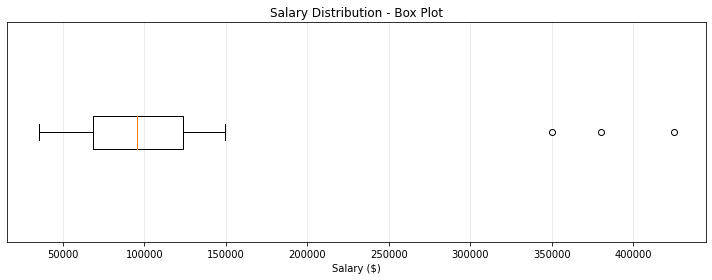

Box plot interpretation:
- The box shows the middle 50% of data (Q1 to Q3)
- The line in the box is the median
- Whiskers extend to 1.5 * IQR
- Points beyond whiskers are outliers


In [37]:
# Simple box plot to visualise salary distribution
plt.figure(figsize=(10, 4))
plt.boxplot(df['salary'], vert=False)
plt.xlabel('Salary ($)')
plt.title('Salary Distribution - Box Plot')
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Box plot interpretation:")
print("- The box shows the middle 50% of data (Q1 to Q3)")
print("- The line in the box is the median")
print("- Whiskers extend to 1.5 * IQR")
print("- Points beyond whiskers are outliers")

### Comparing outlier detection methods

In [29]:
# Compare which records are identified by each method
print("Outlier detection method comparison:")
print(f"Z-score method (|Z| > 3): {len(salary_outliers_z)} outliers")
print(f"IQR method: {len(salary_outliers_iqr)} outliers")

# Find records identified by both methods
both_methods = set(salary_outliers_z.index) & set(salary_outliers_iqr.index)
print(f"Identified by both methods: {len(both_methods)} outliers")

# IQR is generally more commonly used as it's less sensitive to extreme values
print("\nNote: IQR method is often preferred as it's more robust to extreme values")

Outlier detection method comparison:
Z-score method (|Z| > 3): 3 outliers
IQR method: 3 outliers
Identified by both methods: 3 outliers

Note: IQR method is often preferred as it's more robust to extreme values


### Method 3: Domain knowledge

Sometimes the best way to identify outliers is using domain knowledge.

In [30]:
# Define reasonable ranges based on domain knowledge
# For example, we might know that:
# - Most employees earn between $30,000 and $200,000
# - Age should be between 18 and 70
# - Experience should not exceed age - 18

# Check for unrealistic salary values
unrealistic_salary = df[(df['salary'] < 30000) | (df['salary'] > 200000)]
print(f"Employees with potentially unrealistic salaries: {len(unrealistic_salary)}")
if len(unrealistic_salary) > 0:
    print(unrealistic_salary[['employee_id', 'department', 'salary', 'years_experience']])

Employees with potentially unrealistic salaries: 3
    employee_id department    salary  years_experience
6          1094         HR  350000.0                15
42         1125      Sales  380000.0                 2
50         1028         HR  425000.0                16


In [31]:
# Check for logical inconsistencies
# Experience should generally align with age
df['expected_min_age'] = df['years_experience'] + 18  # Assuming work starts at 18
logical_issues = df[df['age'] < df['expected_min_age']]

print(f"Records with experience vs age inconsistencies: {len(logical_issues)}")
if len(logical_issues) > 0:
    print(logical_issues[['employee_id', 'age', 'years_experience', 'expected_min_age']])

# Clean up temporary column
df = df.drop('expected_min_age', axis=1)

Records with experience vs age inconsistencies: 2
    employee_id   age  years_experience  expected_min_age
38         1134  44.0                32                50
62         1114  44.0                32                50


### Handling outliers: What to do?

Once outliers are identified, you have several options:

1. **Keep them**: If they're legitimate values.
2. **Remove them**: If they're clearly errors.
3. **Cap them**: Replace extreme values with upper/lower bounds.
4. **Transform**: Use log transformation to reduce impact.
5. **Investigate**: Analyse separately or flag for review.

**Important**: Never automatically remove outliers without understanding why they exist!

In [32]:
# Example: Capping outliers (Winsorization)
# Replace values beyond upper_bound with upper_bound
df_capped = df.copy()
df_capped.loc[df_capped['salary'] > upper_bound, 'salary'] = upper_bound
df_capped.loc[df_capped['salary'] < lower_bound, 'salary'] = lower_bound

print(f"Salaries capped at bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"\nSalary statistics before capping:")
print(df['salary'].describe())
print(f"\nSalary statistics after capping:")
print(df_capped['salary'].describe())

Salaries capped at bounds: [0, 205,766]

Salary statistics before capping:
count       150.000000
mean      99242.830000
std       51951.021928
min       35412.000000
25%       68849.750000
50%       95791.000000
75%      123616.250000
max      425000.000000
Name: salary, dtype: float64

Salary statistics after capping:
count       150.000000
mean      95658.150000
std       35372.417519
min       35412.000000
25%       68849.750000
50%       95791.000000
75%      123616.250000
max      205766.000000
Name: salary, dtype: float64


In [33]:
# For this exercise, let's remove the extreme salary outliers
# Keep only records within IQR bounds
print(f"Records before outlier removal: {len(df)}")
df_no_outliers = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)].copy()
print(f"Records after outlier removal: {len(df_no_outliers)}")
print(f"Removed: {len(df) - len(df_no_outliers)} records")

Records before outlier removal: 150
Records after outlier removal: 147
Removed: 3 records


## Summary and best practices

### Data cleaning workflow

1. **Explore** the data first.
2. **Document** all issues found before making any changes.
3. **Handle duplicates** before other cleaning.
4. **Handle missing values** strategically.
5. **Identify outliers** using multiple methods.
6. **Make informed decisions** about handling outliers.
7. **Validate** the cleaned data.
8. **Document** every cleaning decision made and why.

### Key takeaways

**Duplicates:**
- Always check for and remove exact duplicates.
- Consider which occurrence to keep.
- Check specific identifying columns (like IDs).

**Missing values:**
- Understand why values are missing.
- Choose strategy based on percentage of missing data.
- Consider different strategies for different columns.
- Document your imputation method.

**Outliers:**
- Use multiple detection methods.
- Always investigate before removing.
- Consider domain knowledge.
- Document why outliers were handled a certain way.

### Final cleaned dataset

In [34]:
# Remove temporary columns used for analysis
df_clean = df_no_outliers.drop(['salary_zscore'], axis=1)

print("Final cleaned dataset summary:")
print(f"Total records: {len(df_clean)}")
print(f"Total features: {df_clean.shape[1]}")
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")
print("\nData types:")
print(df_clean.dtypes)
print("\nFirst few rows:")
df_clean.head()

Final cleaned dataset summary:
Total records: 147
Total features: 8

Missing values: 0
Duplicate rows: 0

Data types:
employee_id            int64
name                  object
department            object
age                  float64
salary               float64
years_experience       int32
performance_score    float64
remote_work           object
dtype: object

First few rows:


,employee_id,name,department,age,salary,years_experience,performance_score,remote_work
0,1082,Employee_82,Finance,22.0,42357.0,1,4.46,No
1,1143,Employee_143,Engineering,57.0,137634.0,16,4.45,No
2,1032,Employee_32,Finance,44.0,55764.0,1,3.33,Yes
3,1030,Employee_30,HR,49.0,117986.0,29,3.60,No
4,1119,Employee_119,Finance,24.0,40486.0,5,3.08,Yes


In [35]:
# Final statistical summary
print("Cleaned dataset statistics:")
df_clean.describe()

Cleaned dataset statistics:


,employee_id,age,salary,years_experience,performance_score
count,147.000000,147.000000,147.000000,147.000000,147.000000
mean,1075.360544,43.142857,93411.051020,12.122449,3.207551
std,43.493496,11.880109,31979.926778,10.693038,1.227730
min,1001.000000,22.000000,35412.000000,0.000000,1.050000
25%,1038.500000,33.500000,67987.500000,3.000000,2.315000
50%,1075.000000,44.000000,95566.000000,8.000000,3.330000
75%,1112.500000,53.000000,122865.500000,19.000000,4.320000
max,1150.000000,64.000000,149585.000000,43.000000,5.000000


## Practice exercises

Try these exercises to reinforce your learning:

1. **Duplicate detection**: Check if there are any duplicate names (but different employee IDs). What might this indicate?

2. **Missing value strategy**: Try filling the age missing values with mean instead of median. Compare the results. Which is better and why?

3. **Outlier investigation**: For the performance_score column, identify outliers using the IQR method. Should these be removed or kept?

4. **Group-based analysis**: Calculate and compare the median salary for each department. Are there any departments that seem unusual?

5. **Validation**: Create a function that validates the cleaned data by checking:
   - no duplicate employee IDs,
   - no missing values,
   - all ages between 18–70,
   - all experience values <= age – 18,
   - all salaries > 0

In [36]:
# Space for your practice code
